In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score
import re

df = pd.read_excel(r"wazuh_mordor_comb-post-refinement.xlsx")

In [2]:
df.columns

Index(['ts', 'computer', 'event_id', 'image', 'command_line', 'target_object',
       'message', 'level', 'source', 'label'],
      dtype='object')

In [3]:
df['target_object'].value_counts

<bound method IndexOpsMixin.value_counts of 0                                                     NaN
1                                                     NaN
2                                                     NaN
3                                                     NaN
4                                                     NaN
                              ...                        
8570                                                  NaN
8571                                                  NaN
8572    HKU\S-1-5-21-3125456671-949036322-3048627137-1...
8573                                                  NaN
8574                                                  NaN
Name: target_object, Length: 8575, dtype: object>

In [4]:
df = df.drop('computer', axis=1)
df = df.drop('source', axis=1)

In [5]:
df.columns

Index(['ts', 'event_id', 'image', 'command_line', 'target_object', 'message',
       'level', 'label'],
      dtype='object')

In [6]:
df["ts"] = pd.to_datetime(df["ts"], utc=True, errors="coerce")

df["hour"] = df["ts"].dt.hour
df["weekday"] = df["ts"].dt.dayofweek

df = df.drop('ts', axis=1)

In [7]:
df.columns

Index(['event_id', 'image', 'command_line', 'target_object', 'message',
       'level', 'label', 'hour', 'weekday'],
      dtype='object')

In [8]:
num_cols = ["event_id", "level"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")


In [9]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing.head(15))

target_object    85.352770
command_line     83.206997
image            59.743440
level             7.638484
weekday           0.034985
hour              0.034985
event_id          0.000000
message           0.000000
label             0.000000
dtype: float64


In [10]:
text_cols = ["image", "command_line", "target_object", "message"]
for c in text_cols:
    df[c] = df[c].astype(str).fillna("")

In [11]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing.head(15))

level            7.638484
weekday          0.034985
hour             0.034985
event_id         0.000000
image            0.000000
message          0.000000
target_object    0.000000
command_line     0.000000
label            0.000000
dtype: float64


In [12]:
df["event_id"].value_counts

<bound method IndexOpsMixin.value_counts of 0       4688
1       4688
2          1
3       4688
4       4673
        ... 
8570      10
8571       7
8572      12
8573      10
8574      10
Name: event_id, Length: 8575, dtype: int64>

In [13]:
for c in ['hour', 'weekday', "level"]:
    df[c] = df[c].fillna(df[c].median())

In [14]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing.head(15))

event_id         0.0
image            0.0
command_line     0.0
target_object    0.0
message          0.0
level            0.0
label            0.0
hour             0.0
weekday          0.0
dtype: float64


In [15]:
df["label"].value_counts

<bound method IndexOpsMixin.value_counts of 0       0
1       0
2       0
3       0
4       0
       ..
8570    1
8571    1
8572    1
8573    1
8574    1
Name: label, Length: 8575, dtype: int64>

In [16]:
df["text_all"] = (
    df["image"].fillna("") + " " +
    df["command_line"].fillna("") + " " +
    df["target_object"].fillna("") + " " +
    df["message"].fillna("")
).str.lower()

In [17]:
USER_GENERAL = re.compile(r'\b[a-zA-Z][a-zA-Z0-9_\-]{2,20}\b')
df["text_all"] = df["text_all"].apply(lambda s: USER_GENERAL.sub("<USER>", s))

In [ ]:
text_col = 'text_all'
num_cols = ['event_id', 'hour', 'weekday', 'level']


y = df["label"].to_numpy()
X = df[[text_col] + num_cols].copy()

#stratified split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


preprocess = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2)), "text_all"),
        ("num", "passthrough", ["event_id", "level", "hour", "weekday"]),
    ],
    sparse_threshold=1.0
)

clf = Pipeline([
    ("prep", preprocess),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1))
])


clf.fit(Xtr, ytr)
pred = clf.predict(Xte)
proba = clf.predict_proba(Xte)[:,1]

print(classification_report(yte, pred, digits=3))
print("PR-AUC:", average_precision_score(yte, proba))
print("ROC-AUC:", roc_auc_score(yte, proba))





              precision    recall  f1-score   support

           0      1.000     0.962     0.981      1460
           1      0.823     1.000     0.903       255

    accuracy                          0.968      1715
   macro avg      0.911     0.981     0.942      1715
weighted avg      0.974     0.968     0.969      1715

PR-AUC: 0.9876933189518893
ROC-AUC: 0.9978686543110394


Confusion Matrix:
 [[1405   55]
 [   0  255]]


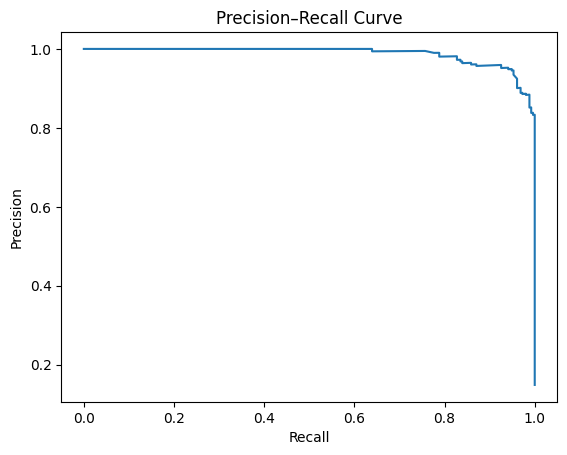

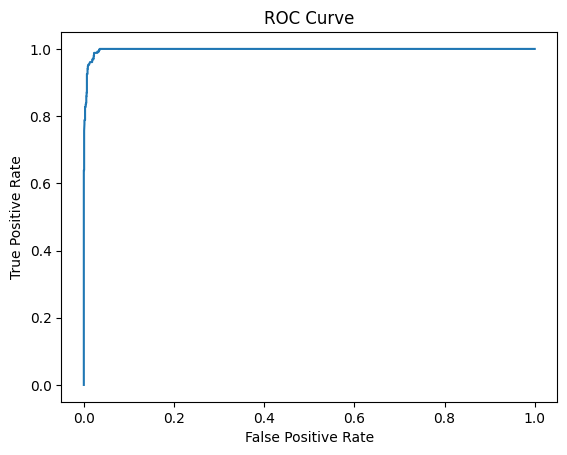

In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

#conf matrix
cm = confusion_matrix(yte, pred)
print("Confusion Matrix:\n", cm)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig("lr_cm.png", dpi=300, bbox_inches="tight")
plt.close()

#precision recall
prec, rec, _ = precision_recall_curve(yte, proba)

plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

#reciever operating curve
fpr, tpr, _ = roc_curve(yte, proba)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
